### 1. Setup and Parameters
Importing libraries and defining constraints

In [1]:
import pandas as pd
import geopandas as gpd
import random
import time as tm
import numpy as np
import matplotlib.pyplot as plt

random.seed(42)

BUDGET = 311
MAX_ASSIGNMENTS_PER_HELI = 20
MAX_STATION_CAPACITY = 1
DISTANCE_LIMIT_KM = 150.0

HELI_TYPES = {
    0: {"name": "None", "cost": 0, "water": 0},
    1: {"name": "Type_1", "cost": 30, "water": 700},
    2: {"name": "Type_2", "cost": 10, "water": 300},
    3: {"name": "Type_3", "cost": 4, "water": 180},
}



### 2. Data Loading
Loading the geospatial data

Calculating the minimum distances between stations and grids

In [2]:


def load_data():
    df_risk = pd.read_csv("Rj_Risk_Matrisi.csv")
    grid_ids = sorted(df_risk["Grid_ID"].unique())
    risk_by_grid = df_risk.set_index("Grid_ID")["R_j"].to_dict()

    gdf_stations = gpd.read_file("cleaned_data/helipads_clean.geojson", on_invalid="ignore")
    station_ids = sorted(gdf_stations["Istasyon_ID"].unique())

    gdf_su = gpd.read_file("cleaned_data/water_clean.geojson", on_invalid="ignore").to_crs(epsg=32635)
    gdf_stations = gdf_stations.to_crs(epsg=32635)

    df_grid = pd.read_csv("Grid_Coordinates.csv")
    gdf_grid = gpd.GeoDataFrame(
        df_grid, geometry=gpd.points_from_xy(df_grid.lon, df_grid.lat), crs="EPSG:4326"
    ).to_crs(epsg=32635)

    istasyon_su_join = gpd.sjoin_nearest(
        gdf_stations, gdf_su, how="left", distance_col="s_i"
    )
    s_i_df = istasyon_su_join.groupby("Istasyon_ID")["s_i"].min().reset_index()

    grid_su_join = gpd.sjoin_nearest(gdf_grid, gdf_su, how="left", distance_col="w_j")
    w_j_df = grid_su_join.groupby("Grid_ID")["w_j"].min().reset_index()

    alpha = 5
    dist_by_pair = {}
    for i_row in s_i_df.itertuples():
        for j_row in w_j_df.itertuples():
            dist_by_pair[(i_row.Istasyon_ID, j_row.Grid_ID)] = (
                i_row.s_i + (alpha + 1) * j_row.w_j
            ) / 1000.0

    return station_ids, grid_ids, risk_by_grid, dist_by_pair

### 3. Genetic Algorithm Class
This class handles the evolutionary process

Inlcluding basic GA functions such as fitness calculation,selection, crossover, and mutation

In [3]:

class HeliFireGA:
    def __init__(
        self,
        station_ids,
        grid_ids,
        risk_by_grid,
        dist_by_pair,
        pop_size=50,
        generations=100,
    ):
        self.station_ids = station_ids
        self.grid_ids = grid_ids
        self.risk_by_grid = risk_by_grid
        self.dist_by_pair = dist_by_pair
        self.pop_size = pop_size
        self.generations = generations
        self.mutation_rate = 0.3
        self.elite_count = 2

    def enforce_budget(self, individual):
        total_cost = sum(HELI_TYPES[h_type]["cost"] for h_type in individual)

        while total_cost > BUDGET:
            active = [i for i, h in enumerate(individual) if h > 0]
            if not active:
                break

            active.sort(
                key=lambda idx: HELI_TYPES[individual[idx]]["cost"]
                / HELI_TYPES[individual[idx]]["water"],
                reverse=True,
            )

            remove_idx = active[0]
            total_cost -= HELI_TYPES[individual[remove_idx]]["cost"]
            individual[remove_idx] = 0

        return individual

    def create_individual(self):

        ind = []
        for _ in range(len(self.station_ids)):
            if random.random() < 0.20:
                ind.append(random.choice([1, 2, 3]))
            else:
                ind.append(0)

        return self.enforce_budget(ind)

    def assign_grids(self, individual):
        active_stations = [
            self.station_ids[i] for i, h_type in enumerate(individual) if h_type > 0
        ]
        station_load = {station_id: 0 for station_id in active_stations}
        assignments = {}
        total_dist_risk = 0.0
        unreachable_risk = 0.0
        overload_penalty = 0.0

        for j in self.grid_ids:
            risk = self.risk_by_grid.get(j, 0.0)
            if risk <= 0:
                continue

            candidates = []
            for station_id in active_stations:
                d = self.dist_by_pair.get((station_id, j), float("inf"))
                if d <= DISTANCE_LIMIT_KM:
                    candidates.append((d, station_id))

            if not candidates:
                unreachable_risk += risk
                continue

            candidates.sort(key=lambda x: x[0])
            assigned = False
            for d, station_id in candidates:
                if station_load[station_id] < MAX_ASSIGNMENTS_PER_HELI:
                    assignments[j] = station_id
                    station_load[station_id] += 1
                    total_dist_risk += risk * d
                    assigned = True
                    break

            if not assigned:
                d, station_id = candidates[0]
                assignments[j] = station_id
                station_load[station_id] += 1
                total_dist_risk += risk * d
                overload_penalty += (
                    station_load[station_id] - MAX_ASSIGNMENTS_PER_HELI
                ) * 1000

        return (
            assignments,
            station_load,
            total_dist_risk,
            unreachable_risk,
            overload_penalty,
        )

    def calculate_fitness(self, individual):

        total_water = sum(HELI_TYPES[h_type]["water"] for h_type in individual)

        (
            assignments,
            station_load,
            total_dist_risk,
            unreachable_risk,
            overload_penalty,
        ) = self.assign_grids(individual)

        if not assignments:
            return 1e8

        unreachable_penalty = unreachable_risk * 1000
        return (
            total_dist_risk
            + unreachable_penalty
            + overload_penalty
            - 0.001 * total_water
        )

    def tournament_select(self, scored, k=5):
        candidates = random.sample(scored, min(k, len(scored)))
        return min(candidates, key=lambda x: x[0])[1]

    def crossover(self, parent1, parent2):
        split = random.randint(1, len(self.station_ids) - 2)
        child = parent1[:split] + parent2[split:]
        return self.enforce_budget(child)

    def mutate(self, individual):
        if random.random() < self.mutation_rate:
            idx = random.randrange(len(self.station_ids))
            individual[idx] = random.choice([0, 1, 2, 3])
        return self.enforce_budget(individual)

    def evolve(self):
        population = [self.create_individual() for _ in range(self.pop_size)]
        history = []
        best_solution = None
        best_score = float("inf")

        start_time = tm.perf_counter()
        for gen in range(self.generations):
            scored = [(self.calculate_fitness(ind), ind) for ind in population]
            scored.sort(key=lambda x: x[0])
            elite = [ind for _, ind in scored[: self.elite_count]]
            current_best_score = scored[0][0]
            history.append(current_best_score)

            if current_best_score < best_score:
                best_score = current_best_score
                best_solution = scored[0][1]

            if gen % 10 == 0 or gen == self.generations - 1:
                print(f"Generation {gen}: Best score = {current_best_score:.2f}")

            next_gen = elite.copy()
            while len(next_gen) < self.pop_size:
                parent1 = self.tournament_select(scored)
                parent2 = self.tournament_select(scored)
                child = self.crossover(parent1, parent2)
                child = self.mutate(child)
                next_gen.append(child)

            population = next_gen

        end_time = tm.perf_counter()
        return best_solution, best_score, end_time - start_time, history

    def decode_solution(self, individual):
        (
            assignments,
            station_load,
            total_dist_risk,
            unreachable_risk,
            overload_penalty,
        ) = self.assign_grids(individual)
        total_cost = sum(HELI_TYPES[h_type]["cost"] for h_type in individual)
        total_water = sum(HELI_TYPES[h_type]["water"] for h_type in individual)
        active_count = sum(1 for h_type in individual if h_type > 0)
        unreachable_count = sum(
            1
            for j in self.grid_ids
            if self.risk_by_grid.get(j, 0.0) > 0 and j not in assignments
        )

        return {
            "total_cost": total_cost,
            "total_water": total_water,
            "active_count": active_count,
            "assigned_grids": len(assignments),
            "unreachable_grids": unreachable_count,
            "total_dist_risk": total_dist_risk,
            "unreachable_risk": unreachable_risk,
            "overload_penalty": overload_penalty,
            "objective": total_dist_risk
            + unreachable_risk * 1000
            + overload_penalty
            - 0.001 * total_water,
            "assignments": assignments,
            "station_load": station_load,
        }



### 4. Execution and Results
Running the Genetic Algorithm for 100 generations

Printing the final helicopter allocation along with the convergence chart

Generation 0: Best score = 1143.01
Generation 10: Best score = 1138.10
Generation 20: Best score = 1136.80
Generation 30: Best score = 1136.62
Generation 40: Best score = 1136.62
Generation 50: Best score = 1136.62
Generation 60: Best score = 1136.33
Generation 70: Best score = 1135.82
Generation 80: Best score = 1135.82
Generation 90: Best score = 1135.82
Generation 99: Best score = 1135.82

GENETIC ALGORITHM RESULT
Computing Time: 126.4421 seconds
Total Money Spent: 310 Million $ (Limit: 311)
Total Water Capacity: 12000 Gallons
Active Station Count: 58
Assigned Grids: 294
Best Objective Score: 1135.82

HELICOPTER ALLOCATION
Station ID	Heli Type	Water(Gal)
Station 2	Type_3	180		4
Station 4	Type_3	180		4
Station 6	Type_3	180		4
Station 10	Type_3	180		4
Station 12	Type_3	180		4
Station 13	Type_3	180		4
Station 16	Type_3	180		4
Station 17	Type_3	180		4
Station 18	Type_3	180		4
Station 22	Type_3	180		4
Station 23	Type_3	180		4
Station 27	Type_3	180		4
Station 28	Type_3	180		4
Station 34	T

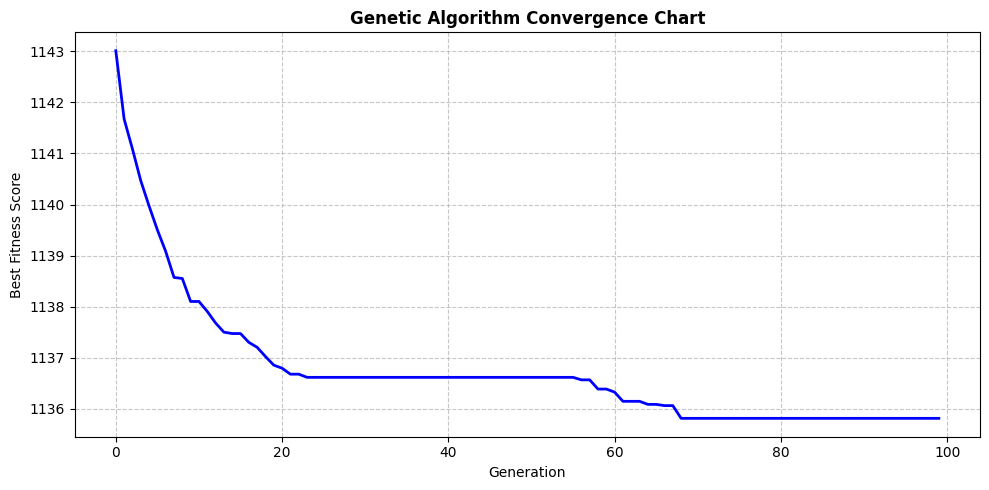

In [6]:
def print_final_report(
    best_ind,
    best_score,
    exec_time,
    history,
    station_ids,
    grid_ids,
    risk_by_grid,
    dist_by_pair,
):
    metrics = HeliFireGA(
        station_ids, grid_ids, risk_by_grid, dist_by_pair
    ).decode_solution(best_ind)

    print("\nGENETIC ALGORITHM RESULT")
    print(f"Computing Time: {exec_time:.4f} seconds")
    print(f"Total Money Spent: {metrics['total_cost']} Million $ (Limit: 311)")
    print(f"Total Water Capacity: {metrics['total_water']} Gallons")
    print(f"Active Station Count: {metrics['active_count']}")
    print(f"Assigned Grids: {metrics['assigned_grids']}")
    print(f"Best Objective Score: {best_score:.2f}\n")

    print("HELICOPTER ALLOCATION")
    print("Station ID\tHeli Type\tWater(Gal)")

    type_counts = {"Type_1": 0, "Type_2": 0, "Type_3": 0}

    for i, h_type in enumerate(best_ind):
        if h_type > 0:
            h_info = HELI_TYPES[h_type]
            h_name = h_info["name"]
            w = h_info["water"]
            c = h_info["cost"]
            st_id = station_ids[i]
            
            print(f"Station {st_id}\t{h_name}\t{w}\t\t{c}")
            type_counts[h_name] += 1

    print("\nSUMMARY BY TYPE")
    print(f"Type_1: {type_counts['Type_1']} Units")
    print(f"Type_2: {type_counts['Type_2']} Units")
    print(f"Type_3: {type_counts['Type_3']} Units")

    plt.figure(figsize=(10, 5))
    plt.plot(history, linewidth=2, color="blue")
    plt.title("Genetic Algorithm Convergence Chart", fontweight="bold")
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness Score")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig("genetic_convergence.png", dpi=300)


if __name__ == "__main__":
    st_ids, gr_ids, r_dict, d_pair = load_data()
    top_grids = [j for j in gr_ids if r_dict[j] > 0.0]

    ga = HeliFireGA(st_ids, top_grids, r_dict, d_pair, pop_size=100, generations=100)
    best_solution, best_score, duration, history = ga.evolve()

    print_final_report(
        best_solution, best_score, duration, history, st_ids, top_grids, r_dict, d_pair
    )

### VISUALAZATION


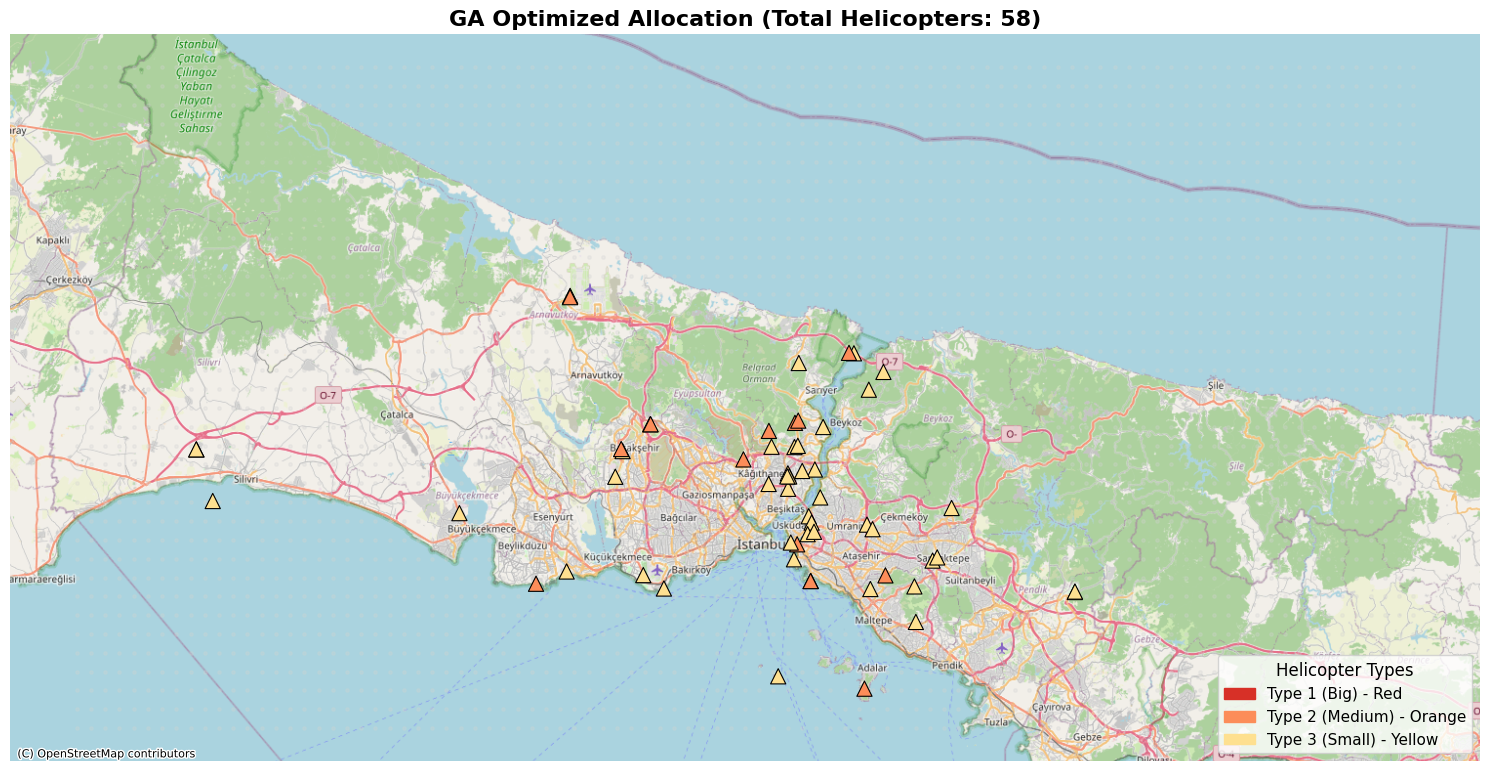

In [12]:
import contextily as ctx
import matplotlib.patches as mpatches

gdf_grid_3857 = gdf_grid.to_crs(epsg=3857)
gdf_active_st_3857 = gdf_active_st.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(15, 10))


gdf_grid_3857.plot(
    ax=ax,
    color='lightgrey',
    edgecolor=None,
    markersize=6,
    alpha=0.25
)

gdf_active_st_3857.plot(
    ax=ax,
    marker='^',
    color=gdf_active_st_3857['color'],
    edgecolor='black',
    linewidth=0.8,
    markersize=120,
    zorder=5
)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=10)

ax.set_title(f"GA Optimized Allocation (Total Helicopters: {len(gdf_active_st)})",
             fontweight="bold", fontsize=16)
ax.axis('off')

leg_t1 = mpatches.Patch(color=type_colors[1], label='Type 1 (Big) - Red')
leg_t2 = mpatches.Patch(color=type_colors[2], label='Type 2 (Medium) - Orange')
leg_t3 = mpatches.Patch(color=type_colors[3], label='Type 3 (Small) - Yellow')
plt.legend(handles=[leg_t1, leg_t2, leg_t3], title="Helicopter Types",
           loc='lower right', title_fontsize=12, fontsize=11)

plt.tight_layout()
plt.show()